# Labraries

In [1]:
"""
Cell 1 — Environment Setup & Version Verification
Purpose : Import all required libraries with version validation.
Research justification: Reproducible environments require explicit version
                        control per IEEE reproducibility standards.
"""

import logging
import sys
import os
import random
import warnings

warnings.filterwarnings("ignore")

# ── Configure logging ──────────────────────────────────────────────────────────
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s",
    datefmt="%H:%M:%S",
)
logger = logging.getLogger(__name__)

# ── Core scientific stack ──────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.model_selection import train_test_split

# ── Deep learning stack ────────────────────────────────────────────────────────
import torch
from transformers import (
    AutoTokenizer,
    AutoModelForSeq2SeqLM,
    DataCollatorForSeq2Seq,
    Seq2SeqTrainer,
    Seq2SeqTrainingArguments,
)
from torch.utils.data import Dataset

# ── Version report ─────────────────────────────────────────────────────────────
logger.info("=" * 60)
logger.info("ENVIRONMENT VERIFICATION")
logger.info("=" * 60)
logger.info(f"Python       : {sys.version}")
logger.info(f"PyTorch      : {torch.__version__}")
logger.info(f"CUDA avail.  : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    logger.info(f"CUDA version : {torch.version.cuda}")
    logger.info(f"GPU          : {torch.cuda.get_device_name(0)}")
    logger.info(f"GPU Memory   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
import transformers
logger.info(f"Transformers : {transformers.__version__}")
import sklearn
logger.info(f"Scikit-learn : {sklearn.__version__}")
logger.info("=" * 60)


13:11:06 | INFO | ============================================================
13:11:06 | INFO | ENVIRONMENT VERIFICATION
13:11:06 | INFO | ============================================================
13:11:06 | INFO | Python       : 3.10.0 (tags/v3.10.0:b494f59, Oct  4 2021, 19:00:18) [MSC v.1929 64 bit (AMD64)]
13:11:06 | INFO | PyTorch      : 2.11.0+cu128
13:11:06 | INFO | CUDA avail.  : True
13:11:06 | INFO | CUDA version : 12.8
13:11:06 | INFO | GPU          : NVIDIA GeForce RTX 4060
13:11:06 | INFO | GPU Memory   : 8.59 GB
13:11:06 | INFO | Transformers : 4.46.3
13:11:06 | INFO | Scikit-learn : 1.7.2
13:11:06 | INFO | ============================================================


In [2]:
"""
Cell 2 — Load, Validate and Profile Parallel Corpus

Purpose
-------
Load the Khowar-English parallel corpus, validate integrity,
remove invalid examples and generate corpus statistics.

Research Justification
----------------------
Parallel corpus quality directly impacts multilingual transfer
learning performance in mBART-50.

Following MT best practices, we:

• remove null examples
• remove duplicate sentence pairs
• inspect sentence lengths
• optionally cap corpus size for debugging
• filter excessively long samples

Khowar is unsupported in mBART-50 and is represented
through Urdu (ur_PK) as a proxy language.

"""

def load_and_validate_dataset(
    filepath: str,
    source_col: str = "example_khowar",
    target_col: str = "example_english",
    max_rows: int = 1050,
    max_char_length: int = 512,
) -> pd.DataFrame:

    logger.info(f"Loading dataset from: {filepath}")

    try:

        df_raw = pd.read_csv(
            filepath,
            encoding="utf-8"
        )

    except FileNotFoundError:

        raise FileNotFoundError(

            f"Dataset not found at '{filepath}'."

        )

    logger.info(f"Raw shape: {df_raw.shape}")

    # ───────────────────────────────────────────────
    # Clean column names
    # ───────────────────────────────────────────────

    df_raw.columns = df_raw.columns.str.strip()

    required = {source_col, target_col}

    missing = required - set(df_raw.columns)

    if missing:

        raise ValueError(

            f"Missing columns: {missing}\n"

            f"Available columns:\n"

            f"{list(df_raw.columns)}"

        )

    df = df_raw[[

        source_col,

        target_col

    ]].copy()

    logger.info(f"\n{'='*60}")

    logger.info("DATASET QUALITY REPORT")

    logger.info(f"{'='*60}")

    logger.info(f"Raw rows            : {len(df)}")

    logger.info(

        f"\nMissing values\n"

        f"{df.isnull().sum()}"

    )

    missing_pct = (

        df.isnull().sum()

        / len(df)

        * 100

    )

    logger.info(

        f"\nMissing percentage\n"

        f"{missing_pct.round(2)}"

    )

    dup_count = df.duplicated().sum()

    logger.info(

        f"Duplicate pairs     : "

        f"{dup_count}"

    )

    # ───────────────────────────────────────────────
    # Remove nulls
    # ───────────────────────────────────────────────

    before = len(df)

    df.dropna(inplace=True)

    logger.info(

        f"After dropna        : "

        f"{len(df)} "

        f"(removed {before-len(df)})"

    )

    # ───────────────────────────────────────────────
    # Remove duplicates
    # ───────────────────────────────────────────────

    before = len(df)

    df.drop_duplicates(

        inplace=True

    )

    logger.info(

        f"After dedup         : "

        f"{len(df)} "

        f"(removed {before-len(df)})"

    )

    # ───────────────────────────────────────────────
    # Length statistics
    # ───────────────────────────────────────────────

    df["src_len"] = (

        df[source_col]

        .astype(str)

        .apply(len)

    )

    df["tgt_len"] = (

        df[target_col]

        .astype(str)

        .apply(len)

    )

    logger.info(f"\n{'='*60}")

    logger.info("LENGTH STATISTICS")

    logger.info(f"{'='*60}")

    logger.info(

        f"Mean source length : "

        f"{df['src_len'].mean():.2f}"

    )

    logger.info(

        f"Mean target length : "

        f"{df['tgt_len'].mean():.2f}"

    )

    logger.info(

        f"Maximum source len : "

        f"{df['src_len'].max()}"

    )

    logger.info(

        f"Maximum target len : "

        f"{df['tgt_len'].max()}"

    )

    # ───────────────────────────────────────────────
    # Filter long sentences
    # ───────────────────────────────────────────────

    before = len(df)

    df = df[

        (df["src_len"] < max_char_length)

        &

        (df["tgt_len"] < max_char_length)

    ]

    logger.info(

        f"After length filter: "

        f"{len(df)} "

        f"(removed {before-len(df)})"

    )

    # ───────────────────────────────────────────────
    # Optional subsampling
    # ───────────────────────────────────────────────

    if max_rows is not None:

        if len(df) > max_rows:

            logger.warning(

                f"Capping dataset "

                f"to {max_rows} rows"

            )

            df = df.iloc[:max_rows]

    df.reset_index(

        drop=True,

        inplace=True

    )

    logger.info(f"\n{'='*60}")

    logger.info(

        f"Final shape : "

        f"{df.shape}"

    )

    logger.info(f"{'='*60}")

    return df


# ---------------------------------------------------
# Dataset configuration
# ---------------------------------------------------

DATA_PATH = os.environ.get(

    "KHOWAR_DATA_PATH",

    "Khowar_English_Dataset.csv"

)

df1 = load_and_validate_dataset(

    DATA_PATH,

    source_col="example_khowar",

    target_col="example_english",

    max_rows=1050

)

df1.head()



13:11:06 | INFO | Loading dataset from: Khowar_English_Dataset.csv
13:11:06 | INFO | Raw shape: (1049, 9)
13:11:06 | INFO | 
13:11:06 | INFO | DATASET QUALITY REPORT
13:11:06 | INFO | ============================================================
13:11:06 | INFO | Raw rows            : 1049
13:11:06 | INFO | 
Missing values
example_khowar     1
example_english    1
dtype: int64
13:11:06 | INFO | 
Missing percentage
example_khowar     0.1
example_english    0.1
dtype: float64
13:11:06 | INFO | Duplicate pairs     : 0
13:11:06 | INFO | After dropna        : 1048 (removed 1)
13:11:06 | INFO | After dedup         : 1048 (removed 0)
13:11:06 | INFO | 
13:11:06 | INFO | LENGTH STATISTICS
13:11:06 | INFO | ============================================================
13:11:06 | INFO | Mean source length : 23.75
13:11:06 | INFO | Mean target length : 37.18
13:11:06 | INFO | Maximum source len : 50
13:11:06 | INFO | Maximum target len : 123
13:11:06 | INFO | After length filter: 1048 (removed 0)
1

,example_khowar,example_english,src_len,tgt_len
0,ہیس دورو اباد اریر۔,He got the house settled and functioning prope...,19,50
1,ڈقو اپاک ݯھموران,The boy's mouth is hurting.,16,27
2,ای اپاک لو دی نو پراے۔,He/she didn't even say a single sentence.,23,41
3,تہ اپاک زوالو۔,Your mouth is sweet.,14,20
4,مہ پیٹیک ا ترو ݯی شیر۔,My scarf is torn.,22,17


In [3]:
import unicodedata
import re
from typing import Optional



##############################################################################
# KHOWAR TEXT NORMALIZATION
#
# Research-Oriented Normalization Pipeline
# Suitable for Low-Resource Machine Translation
#
# This function performs ONLY SAFE NORMALIZATION.
# It does NOT change genuine Khowar spellings.
##############################################################################

# ---------------------------------------------------------------------------
# 1. Arabic Character Mapping
#
# These mappings only normalize different Unicode variants of the SAME letter.
# They DO NOT modify genuine Khowar letters.
# ---------------------------------------------------------------------------

CHAR_MAP = {

    # Yeh variants
    "ي": "ی",
    "ى": "ی",

    # Kaf
    "ك": "ک",

    # Alef variants
    "أ": "ا",
    "إ": "ا",
    "ٱ": "ا",

    # Heh variants
    "ة": "ہ",
    "ۀ": "ہ",

    # Hamza forms
    # Uncomment ONLY if your corpus analysis proves they are interchangeable.
    # "ؤ": "و",
    # "ئ": "ی",
}

# ---------------------------------------------------------------------------
# 2. Arabic Diacritics
#
# Remove optional vowel marks.
# Example:
#
# ژُونوُ  -> ژونو
# ---------------------------------------------------------------------------

DIACRITICS = re.compile(
    r"[\u064B-\u065F\u0670\u06D6-\u06ED]"
)

# ---------------------------------------------------------------------------
# 3. Invisible Unicode Characters
#
# Remove:
# ZWJ
# ZWNJ
# LRM
# RLM
# BOM
# ---------------------------------------------------------------------------

INVISIBLE = re.compile(
    r"[\u200B\u200C\u200D\u200E\u200F\uFEFF]"
)

# ---------------------------------------------------------------------------
# 4. Multiple Spaces
# ---------------------------------------------------------------------------

MULTI_SPACE = re.compile(r"\s+")

# ---------------------------------------------------------------------------
# 5. Duplicate Punctuation
# ---------------------------------------------------------------------------

MULTI_FULLSTOP = re.compile(r"[۔]{2,}")
MULTI_QUESTION = re.compile(r"[؟]{2,}")

# ---------------------------------------------------------------------------
# 6. Main Function
# ---------------------------------------------------------------------------

def normalize_khowar(text: str) -> str:
    """
    Normalize Khowar text for Machine Translation.

    Parameters
    ----------
    text : str
        Raw Khowar sentence.

    Returns
    -------
    str
        Normalized sentence.
    """

    # ------------------------------------------------------------
    # Return empty string for invalid input
    # ------------------------------------------------------------
    if not isinstance(text, str):
        return ""

    # ------------------------------------------------------------
    # Unicode Normalization
    #
    # Convert different Unicode representations
    # into one canonical representation.
    # ------------------------------------------------------------
    text = unicodedata.normalize("NFC", text)

    # ------------------------------------------------------------
    # Remove invisible Unicode characters
    # ------------------------------------------------------------
    text = INVISIBLE.sub("", text)

    # ------------------------------------------------------------
    # Remove Arabic diacritics
    # ------------------------------------------------------------
    text = DIACRITICS.sub("", text)

    # ------------------------------------------------------------
    # Normalize Arabic Unicode variants
    # ------------------------------------------------------------
    for old_char, new_char in CHAR_MAP.items():
        text = text.replace(old_char, new_char)

    # ------------------------------------------------------------
    # Normalize punctuation
    #
    # English punctuation -> Urdu/Perso-Arabic punctuation
    # ------------------------------------------------------------
    text = text.replace(".", "۔")
    text = text.replace("?", "؟")
    text = text.replace(",", "،")

    # ------------------------------------------------------------
    # Remove duplicate punctuation
    #
    # Example:
    # ؟؟؟ -> ؟
    # ۔۔۔۔ -> ۔
    # ------------------------------------------------------------
    text = MULTI_QUESTION.sub("؟", text)
    text = MULTI_FULLSTOP.sub("۔", text)

    # ------------------------------------------------------------
    # Replace tabs/newlines with spaces
    # ------------------------------------------------------------
    text = text.replace("\n", " ")
    text = text.replace("\t", " ")

    # ------------------------------------------------------------
    # Remove extra spaces
    # ------------------------------------------------------------
    text = MULTI_SPACE.sub(" ", text)

    # ------------------------------------------------------------
    # Remove spaces BEFORE punctuation
    #
    # Example:
    # ژونو ۔
    #
    # becomes
    #
    # ژونو۔
    # ------------------------------------------------------------
    text = re.sub(r"\s+([۔؟،])", r"\1", text)

    # ------------------------------------------------------------
    # Ensure ONE space AFTER punctuation
    #
    # Example:
    # ژونو۔اسور
    #
    # becomes
    #
    # ژونو۔ اسور
    # ------------------------------------------------------------
    text = re.sub(r"([۔؟،])([^\s])", r"\1 \2", text)

    # ------------------------------------------------------------
    # Remove leading/trailing spaces
    # ------------------------------------------------------------
    text = text.strip()

    return text




def normalize_english(text: str) -> str:
    """
    Normalize English text for Machine Translation.
    Applies only safe, deterministic transformations.
    """

    if not isinstance(text, str):
        return ""
    

    # Invisible Unicode characters
    INVISIBLE = re.compile(r"[\u200B\u200C\u200D\u200E\u200F\uFEFF]")

    # Multiple spaces 
    MULTI_SPACE = re.compile(r"\s+")

    # Duplicate punctuation
    MULTI_DOTS = re.compile(r"\.{4,}")
    MULTI_QMARK = re.compile(r"\?{2,}")
    MULTI_EXCL = re.compile(r"\!{2,}")

    # Unicode normalization
    text = unicodedata.normalize("NFC", text)

    # Remove invisible characters
    text = INVISIBLE.sub("", text)

    # Normalize quotation marks
    text = (text.replace("“", '"')
                .replace("”", '"')
                .replace("„", '"')
                .replace("‟", '"')
                .replace("‘", "'")
                .replace("’", "'")
                .replace("`", "'")
                .replace("´", "'"))

    # Normalize dashes
    text = (text.replace("–", "-")
                .replace("—", "-")
                .replace("−", "-"))

    # Normalize ellipsis
    text = MULTI_DOTS.sub("...", text)

    # Remove duplicate punctuation
    text = MULTI_QMARK.sub("?", text)
    text = MULTI_EXCL.sub("!", text)

    # Replace tabs/newlines with spaces
    text = text.replace("\n", " ").replace("\t", " ")

    # Collapse multiple spaces
    text = MULTI_SPACE.sub(" ", text)

    # Remove spaces before punctuation
    text = re.sub(r"\s+([.,!?;:])", r"\1", text)

    # Ensure one space after punctuation
    text = re.sub(r"([.,!?;:])([^\s])", r"\1 \2", text)

    # Trim
    return text.strip()










def normalize_corpus(
    df: pd.DataFrame,
    source_col: str = "example_khowar",
    target_col: str = "example_english",
) -> pd.DataFrame:
    """
    Normalize a parallel Khowar-English corpus.

    This function applies:
        1. Khowar normalization
        2. English normalization
        3. Removes empty sentence pairs
        4. Removes duplicate sentence pairs
        5. Resets DataFrame index

    Parameters
    ----------
    df : pd.DataFrame
        Input parallel corpus.

    source_col : str
        Name of the Khowar column.

    target_col : str
        Name of the English column.

    Returns
    -------
    pd.DataFrame
        Cleaned and normalized corpus.
    """

    logger.info("Starting corpus normalization...")

    df = df.copy()

    # Replace missing values with empty strings
    df[source_col] = df[source_col].fillna("")
    df[target_col] = df[target_col].fillna("")

    # Normalize Khowar sentences
    df[source_col] = df[source_col].apply(normalize_khowar)

    # Normalize English sentences
    df[target_col] = df[target_col].apply(normalize_english)

    # Remove empty sentence pairs
    before = len(df)

    df = df[
        (df[source_col].str.strip() != "") &
        (df[target_col].str.strip() != "")
    ]

    logger.info(
        f"Removed {before - len(df)} empty sentence pairs."
    )

    # Remove duplicate sentence pairs
    before = len(df)

    df = df.drop_duplicates(
        subset=[source_col, target_col]
    )

    logger.info(
        f"Removed {before - len(df)} duplicate sentence pairs."
    )

    # Reset DataFrame index
    df.reset_index(drop=True, inplace=True)

    logger.info(
        f"Corpus normalization complete. Final size: {len(df)} sentence pairs."
    )

    return df


df1 = normalize_corpus(df1)
df1.head()


13:11:06 | INFO | Starting corpus normalization...
13:11:06 | INFO | Removed 0 empty sentence pairs.
13:11:06 | INFO | Removed 0 duplicate sentence pairs.
13:11:06 | INFO | Corpus normalization complete. Final size: 1048 sentence pairs.


,example_khowar,example_english,src_len,tgt_len
0,ہیس دورو اباد اریر۔,He got the house settled and functioning prope...,19,50
1,ڈقو اپاک ݯھموران,The boy's mouth is hurting.,16,27
2,ای اپاک لو دی نو پراے۔,He/she didn't even say a single sentence.,23,41
3,تہ اپاک زوالو۔,Your mouth is sweet.,14,20
4,مہ پیٹیک ا ترو ݯی شیر۔,My scarf is torn.,22,17


In [4]:
"""
Cell 4 — Corpus Analysis and Length Filtering

Purpose
-------
Compute corpus-level statistics and remove noisy sentence pairs
prior to mBART-50 fine-tuning.

Research Motivation
-------------------
Neural Machine Translation systems are sensitive to:

• Extremely long sequences
• Source-target length imbalance
• Vocabulary sparsity
• Rare token distributions

Following multilingual MT preprocessing practices,
sentence pairs exhibiting excessive length or
abnormal source-target ratios are discarded.

These statistics are later reported in the
Experimental Setup section of the paper.

"""

from collections import Counter


def analyze_vocabulary(
        series: pd.Series,
        language_name: str
):

    """
    Analyze vocabulary statistics.

    Returns
    -------
    dict

    """

    frequency = Counter()

    sentence_lengths = []

    for sentence in series.dropna():

        tokens = str(sentence).split()

        frequency.update(tokens)

        sentence_lengths.append(

            len(tokens)

        )

    vocabulary_size = len(

        frequency

    )

    singleton_count = sum(

        1

        for c in frequency.values()

        if c == 1

    )

    logger.info(f"\n{'='*60}")

    logger.info(

        f"VOCABULARY REPORT — {language_name}"

    )

    logger.info(f"{'='*60}")

    logger.info(

        f"Vocabulary Size       : "

        f"{vocabulary_size:,}"

    )

    logger.info(

        f"Singleton Tokens      : "

        f"{singleton_count:,}"

    )

    logger.info(

        f"Hapax Percentage      : "

        f"{singleton_count/vocabulary_size*100:.2f}%"

    )

    logger.info(

        f"Average Length        : "

        f"{np.mean(sentence_lengths):.2f}"

    )

    logger.info(

        f"Median Length         : "

        f"{np.median(sentence_lengths):.2f}"

    )

    logger.info(

        f"Maximum Length        : "

        f"{np.max(sentence_lengths)}"

    )

    logger.info(

        f"Minimum Length        : "

        f"{np.min(sentence_lengths)}"

    )

    logger.info(

        f"Top 20 Tokens"

    )

    logger.info(

        frequency.most_common(20)

    )

    return {

        "vocab_size":

            vocabulary_size,

        "singleton_count":

            singleton_count,

        "token_frequency":

            frequency,

        "length_distribution":

            sentence_lengths

    }


def filter_by_length(

        df: pd.DataFrame,

        source_col: str,

        target_col: str,

        max_src_tokens: int = 128,

        max_tgt_tokens: int = 128,

        ratio_threshold: float = 3.0

):

    """
    Remove noisy sentence pairs.

    Filtering criteria
    ------------------

    Source length ≤ 128

    Target length ≤ 128

    Length ratio ≤ 2.5

    """

    df = df.copy()

    df["_src_len"] = (

        df[source_col]

        .apply(

            lambda x:

            len(

                str(x).split()

            )

        )

    )

    df["_tgt_len"] = (

        df[target_col]

        .apply(

            lambda x:

            len(

                str(x).split()

            )

        )

    )

    df["_ratio"] = (

        df[["_src_len", "_tgt_len"]]

        .max(axis=1)

        /

        df[["_src_len", "_tgt_len"]]

        .min(axis=1)

        .clip(lower=1)

    )

    initial_size = len(df)

    df = df[

        (df["_src_len"]

         <= max_src_tokens)

        &

        (df["_tgt_len"]

         <= max_tgt_tokens)

        &

        (df["_ratio"]

         <= ratio_threshold)

    ]

    removed = initial_size - len(df)

    logger.info(f"\n{'='*60}")

    logger.info(

        "LENGTH FILTERING REPORT"

    )

    logger.info(f"{'='*60}")

    logger.info(

        f"Removed Samples      : "

        f"{removed}"

    )

    logger.info(

        f"Removal Percentage   : "

        f"{removed/initial_size*100:.2f}%"

    )

    logger.info(

        f"Remaining Samples    : "

        f"{len(df)}"

    )

    logger.info(f"{'='*60}")

    df.drop(

        columns=[

            "_src_len",

            "_tgt_len",

            "_ratio"

        ],

        inplace=True

    )

    return (

        df

        .reset_index(

            drop=True

        )

    )


# ==========================================================
# Corpus Characterization
# ==========================================================

khowar_stats = analyze_vocabulary(

    df1["example_khowar"],

    "Khowar"

)

english_stats = analyze_vocabulary(

    df1["example_english"],

    "English"

)


# ==========================================================
# Corpus Filtering
# ==========================================================

df1 = filter_by_length(

    df1,

    source_col="example_khowar",

    target_col="example_english",

    max_src_tokens=128,

    max_tgt_tokens=128,

    ratio_threshold=3.0

)

logger.info(

    f"Final Corpus Size: "

    f"{len(df1):,}"

)

df1.head()

13:11:06 | INFO | 
13:11:06 | INFO | VOCABULARY REPORT — Khowar
13:11:06 | INFO | ============================================================
13:11:06 | INFO | Vocabulary Size       : 2,201
13:11:06 | INFO | Singleton Tokens      : 1,564
13:11:06 | INFO | Hapax Percentage      : 71.06%
13:11:06 | INFO | Average Length        : 4.40
13:11:06 | INFO | Median Length         : 4.00
13:11:06 | INFO | Maximum Length        : 11
13:11:06 | INFO | Minimum Length        : 2
13:11:06 | INFO | Top 20 Tokens
13:11:06 | INFO | [('نو', 115), ('مہ', 111), ('بیتی', 70), ('شیر۔', 67), ('بوے۔', 51), ('بو', 38), ('جم', 34), ('ہوے۔', 34), ('کیہ', 34), ('اسور۔', 33), ('اریر۔', 28), ('ای', 26), ('کوری', 25), ('ڈق', 25), ('شینی۔', 24), ('بیراے۔', 22), ('تہ', 21), ('پراے۔', 19), ('ہیہ', 19), ('روے', 19)]
13:11:06 | INFO | 
13:11:06 | INFO | VOCABULARY REPORT — English
13:11:06 | INFO | ============================================================
13:11:06 | INFO | Vocabulary Size       : 2,400
13:11:06 | INFO

,example_khowar,example_english,src_len,tgt_len
0,ہیس دورو اباد اریر۔,He got the house settled and functioning prope...,19,50
1,ڈقو اپاک ݯھموران,The boy's mouth is hurting.,16,27
2,ای اپاک لو دی نو پراے۔,He/she didn't even say a single sentence.,23,41
3,تہ اپاک زوالو۔,Your mouth is sweet.,14,20
4,مہ پیٹیک ا ترو ݯی شیر۔,My scarf is torn.,22,17


In [5]:
"""
Cell 5 — Reproducible Dataset Splitting

Purpose
-------
Create reproducible train, validation and test sets
for mBART-50 fine-tuning.

Research Motivation
-------------------
Reproducible data partitioning is essential for
Neural Machine Translation experiments.

To prevent data leakage:

• train, validation and test sets are mutually exclusive

• split indices are preserved

• splits are exported for reproducibility

Following common MT practice, a
70/15/15 partitioning strategy is adopted.

mBART-50 does not support Khowar.

Urdu (ur_PK) is employed as a proxy language
because Khowar is predominantly written in
an Arabic-derived script.

"""

import pandas as pd

# Load existing splits
train_df = pd.read_csv("splits/train.csv", index_col=0, encoding="utf-8-sig")
val_df   = pd.read_csv("splits/validation.csv", index_col=0, encoding="utf-8-sig")
test_df  = pd.read_csv("splits/test.csv", index_col=0, encoding="utf-8-sig")

# Extract source/target columns
train_kh = train_df["example_khowar"]
train_en = train_df["example_english"]

val_kh = val_df["example_khowar"]
val_en = val_df["example_english"]

test_kh = test_df["example_khowar"]
test_en = test_df["example_english"]

# Quick sanity check
print(f"Train samples: {len(train_df)}")
print(f"Validation samples: {len(val_df)}")
print(f"Test samples: {len(test_df)}")


train_kh = train_df["example_khowar"]

train_en = train_df["example_english"]

val_kh = val_df["example_khowar"]

val_en = val_df["example_english"]

test_kh = test_df["example_khowar"]

test_en = test_df["example_english"]

logger.info(

    f"\nTrain samples : {len(train_df)}"

)

logger.info(

    f"Validation samples : {len(val_df)}"

)

logger.info(

    f"Test samples : {len(test_df)}"

)

13:11:06 | INFO | 
Train samples : 827
13:11:07 | INFO | Validation samples : 103
13:11:07 | INFO | Test samples : 104


Train samples: 827
Validation samples: 103
Test samples: 104


In [6]:
"""
Cell 6 — NLLB-200 Tokenization

Purpose
-------
Prepare multilingual datasets for NLLB-200 training.

Notes
-----
Khowar is unsupported by NLLB-200.

Urdu (urd_Arab) is used as the source language proxy.

English (eng_Latn) is the target language.
"""

# ============================================================
# Imports
# ============================================================

import os
import random
import numpy as np
import torch

from transformers import AutoTokenizer

# ============================================================
# Reproducibility
# ============================================================


RANDOM_SEED = 42   # <-- Add this line

def set_global_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    logger.info(f"Global seed set to {seed}")

set_global_seed(RANDOM_SEED)

# ============================================================
# Model
# ============================================================

MODEL_NAME = "facebook/nllb-200-distilled-600M"

logger.info(f"Loading tokenizer : {MODEL_NAME}")

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME,
    use_fast=True
)

logger.info(f"Tokenizer class : {tokenizer.__class__.__name__}")

logger.info(f"Vocabulary size : {len(tokenizer):,}")

# ============================================================
# Language configuration
# ============================================================

SRC_LANG = "urd_Arab"
TGT_LANG = "eng_Latn"

tokenizer.src_lang = SRC_LANG
tokenizer.tgt_lang = TGT_LANG

logger.info(f"Source Language : {SRC_LANG}")
logger.info(f"Target Language : {TGT_LANG}")

# ============================================================
# Sequence length estimation
# ============================================================

logger.info("Analyzing sequence lengths...")

lengths = []

for src, tgt in zip(train_kh, train_en):

    src_ids = tokenizer(
        str(src),
        add_special_tokens=True
    )["input_ids"]

    tgt_ids = tokenizer(
        text_target=str(tgt),
        add_special_tokens=True
    )["input_ids"]

    lengths.append(len(src_ids))
    lengths.append(len(tgt_ids))

p95 = int(np.percentile(lengths,95))

p99 = int(np.percentile(lengths,99))

MAX_LENGTH = min(p99 + 5,128)

logger.info(f"95th percentile : {p95}")

logger.info(f"99th percentile : {p99}")

logger.info(f"MAX_LENGTH : {MAX_LENGTH}")

# ============================================================
# Tokenization function
# ============================================================

def tokenize_corpus(source_texts,
                    target_texts,
                    max_length=MAX_LENGTH):

    source_texts = list(source_texts)

    target_texts = list(target_texts)

    tokenizer.src_lang = SRC_LANG

    tokenizer.tgt_lang = TGT_LANG

    encoded = tokenizer(

        source_texts,

        text_target=target_texts,

        truncation=True,

        max_length=max_length,

        padding=False,

        return_attention_mask=True

    )

    return encoded

# ============================================================
# Tokenize datasets
# ============================================================

logger.info("Tokenizing training set")

train_tokenized = tokenize_corpus(
    train_kh,
    train_en
)

logger.info("Tokenizing validation set")

val_tokenized = tokenize_corpus(
    val_kh,
    val_en
)

logger.info("Tokenizing test set")

test_tokenized = tokenize_corpus(
    test_kh,
    test_en
)

logger.info(f"Train examples      : {len(train_tokenized['input_ids'])}")

logger.info(f"Validation examples : {len(val_tokenized['input_ids'])}")

logger.info(f"Test examples       : {len(test_tokenized['input_ids'])}")

logger.info("Tokenization completed successfully.")

13:11:07 | INFO | Global seed set to 42
13:11:07 | INFO | Loading tokenizer : facebook/nllb-200-distilled-600M
13:11:09 | INFO | Tokenizer class : NllbTokenizerFast
13:11:09 | INFO | Vocabulary size : 256,204
13:11:09 | INFO | Source Language : urd_Arab
13:11:09 | INFO | Target Language : eng_Latn
13:11:09 | INFO | Analyzing sequence lengths...
13:11:10 | INFO | 95th percentile : 18
13:11:10 | INFO | 99th percentile : 21
13:11:10 | INFO | MAX_LENGTH : 26
13:11:10 | INFO | Tokenizing training set
13:11:10 | INFO | Tokenizing validation set
13:11:10 | INFO | Tokenizing test set
13:11:10 | INFO | Train examples      : 827
13:11:10 | INFO | Validation examples : 103
13:11:10 | INFO | Test examples       : 104
13:11:10 | INFO | Tokenization completed successfully.


In [7]:
"""
Cell 7A — Dataset Construction & NLLB-200 Loading
"""

import torch

from datasets import Dataset

from transformers import (
    AutoModelForSeq2SeqLM,
)

# =====================================================
# Create HuggingFace datasets
# =====================================================

train_dataset = Dataset.from_dict(train_tokenized)
val_dataset   = Dataset.from_dict(val_tokenized)
test_dataset  = Dataset.from_dict(test_tokenized)

logger.info(f"Train samples      : {len(train_dataset):,}")
logger.info(f"Validation samples : {len(val_dataset):,}")
logger.info(f"Test samples       : {len(test_dataset):,}")

# =====================================================
# Load model
# =====================================================

logger.info("=" * 60)
logger.info(f"Loading model : {MODEL_NAME}")
logger.info("=" * 60)

model = AutoModelForSeq2SeqLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float32,
)

logger.info(f"Model class : {model.__class__.__name__}")

logger.info(
    f"Architecture : {model.config.architectures}"
)

logger.info(
    f"Model type : {model.config.model_type}"
)

logger.info(
    f"Vocabulary size : {model.config.vocab_size:,}"
)

logger.info(
    f"Total parameters : "
    f"{sum(p.numel() for p in model.parameters()):,}"
)

first_param = next(model.parameters())

logger.info(
    f"Loaded initially on : {first_param.device}"
)

if first_param.device.type == "meta":
    raise RuntimeError(
        "Model loaded on META device."
    )

13:11:10 | INFO | Train samples      : 827
13:11:10 | INFO | Validation samples : 103
13:11:10 | INFO | Test samples       : 104
13:11:10 | INFO | ============================================================
13:11:10 | INFO | Loading model : facebook/nllb-200-distilled-600M
13:11:10 | INFO | ============================================================
13:11:11 | INFO | Model class : M2M100ForConditionalGeneration
13:11:11 | INFO | Architecture : ['M2M100ForConditionalGeneration']
13:11:11 | INFO | Model type : m2m_100
13:11:11 | INFO | Vocabulary size : 256,206
13:11:11 | INFO | Total parameters : 615,073,792
13:11:11 | INFO | Loaded initially on : cpu


In [8]:
"""
Cell 7B — Language Configuration, GPU Setup & Data Collator
"""

from transformers import DataCollatorForSeq2Seq

# =====================================================
# Configure tokenizer languages
# =====================================================

tokenizer.src_lang = SRC_LANG
tokenizer.tgt_lang = TGT_LANG

logger.info(f"Source language : {SRC_LANG}")
logger.info(f"Target language : {TGT_LANG}")

# =====================================================
# Configure generation language
# =====================================================

forced_bos_token_id = tokenizer.convert_tokens_to_ids(
    TGT_LANG
)

model.config.forced_bos_token_id = forced_bos_token_id

model.generation_config.forced_bos_token_id = (
    forced_bos_token_id
)

logger.info(
    f"Forced BOS token id : {forced_bos_token_id}"
)

# =====================================================
# Move model to GPU
# =====================================================

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = model.to(device)

logger.info(f"Training device : {device}")

logger.info(
    f"Model device : "
    f"{next(model.parameters()).device}"
)

# =====================================================
# Data Collator
# =====================================================

data_collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer,
    model=model,
    padding=True,
    label_pad_token_id=-100,
    return_tensors="pt",
)

logger.info("DataCollator initialized.")

logger.info("=" * 60)
logger.info("NLLB-200 Initialization Completed")
logger.info("=" * 60)


logger.info("=" * 60)
logger.info("Verification")

logger.info(
    f"Model training device : {next(model.parameters()).device}"
)

logger.info(
    f"Tokenizer source language : {tokenizer.src_lang}"
)

logger.info(
    f"Tokenizer target language : {tokenizer.tgt_lang}"
)

logger.info(
    f"Forced BOS token id : {model.generation_config.forced_bos_token_id}"
)

logger.info("=" * 60)

13:11:11 | INFO | Source language : urd_Arab
13:11:11 | INFO | Target language : eng_Latn
13:11:11 | INFO | Forced BOS token id : 256047
13:11:13 | INFO | Training device : cuda
13:11:13 | INFO | Model device : cuda:0
13:11:13 | INFO | DataCollator initialized.
13:11:13 | INFO | ============================================================
13:11:13 | INFO | NLLB-200 Initialization Completed
13:11:13 | INFO | ============================================================
13:11:13 | INFO | ============================================================
13:11:13 | INFO | Verification
13:11:13 | INFO | Model training device : cuda:0
13:11:13 | INFO | Tokenizer source language : urd_Arab
13:11:13 | INFO | Tokenizer target language : eng_Latn
13:11:13 | INFO | Forced BOS token id : 256047
13:11:13 | INFO | ============================================================


In [9]:

import evaluate
from transformers import EarlyStoppingCallback
from comet import download_model, load_from_checkpoint
import torch
import numpy as np
import evaluate

from comet import (
    download_model,
    load_from_checkpoint
)

from transformers import (
    EarlyStoppingCallback,
    Seq2SeqTrainer,
    Seq2SeqTrainingArguments
)


def build_compute_metrics(tokenizer_ref, tgt_lang_code: str):
    """
    Build a compute_metrics function for:
    BLEU, SacreBLEU, chrF, TER, METEOR, BERTScore, COMET.

    Returns a callable compatible with Seq2SeqTrainer.
    """

    sacrebleu = evaluate.load("sacrebleu")
    chrf = evaluate.load("chrf")
    ter = evaluate.load("ter")
    meteor = evaluate.load("meteor")
    bertscore = evaluate.load("bertscore")

    # ── COMET Model ───────────────────────────────────────────
    comet_model_path = download_model(
        "Unbabel/wmt22-comet-da"
    )

    comet_model = load_from_checkpoint(
        comet_model_path
    )

    def compute_metrics(eval_preds):
        preds, labels = eval_preds

        # Replace -100 in labels (masked padding)
        labels = np.where(
            labels != -100,
            labels,
            tokenizer_ref.pad_token_id
        )

        # Decode predictions and labels
        decoded_preds = tokenizer_ref.batch_decode(
            preds,
            skip_special_tokens=True
        )

        decoded_labels = tokenizer_ref.batch_decode(
            labels,
            skip_special_tokens=True
        )

        # SacreBLEU expects list of references wrapped in a list
        decoded_labels_wrapped = [
            [ref] for ref in decoded_labels
        ]

        # ── BLEU / SacreBLEU ──────────────────────────────────
        bleu_result = sacrebleu.compute(
            predictions=decoded_preds,
            references=decoded_labels_wrapped
        )

        # ── chrF ──────────────────────────────────────────────
        chrf_result = chrf.compute(
            predictions=decoded_preds,
            references=decoded_labels_wrapped
        )

        # ── TER ───────────────────────────────────────────────
        ter_result = ter.compute(
            predictions=decoded_preds,
            references=decoded_labels_wrapped
        )

        # ── METEOR ────────────────────────────────────────────
        meteor_result = meteor.compute(
            predictions=decoded_preds,
            references=decoded_labels
        )

        # ── BERTScore ─────────────────────────────────────────
        bertscore_result = bertscore.compute(
            predictions=decoded_preds,
            references=decoded_labels,
            lang="en"
        )

        bertscore_f1 = np.mean(
            bertscore_result["f1"]
        )

        # ── COMET ─────────────────────────────────────────────
        comet_data = [
            {
                "src": "",
                "mt": pred,
                "ref": ref
            }
            for pred, ref in zip(
                decoded_preds,
                decoded_labels
            )
        ]

        comet_output = comet_model.predict(
            comet_data,
            batch_size=8,
            gpus=1 if torch.cuda.is_available() else 0
        )

        comet_score = comet_output.system_score

        return {
            "bleu": round(
                bleu_result["score"], 4
            ),

            "sacrebleu": round(
                bleu_result["score"], 4
            ),

            "chrf": round(
                chrf_result["score"], 4
            ),

            "ter": round(
                ter_result["score"], 4
            ),

            "meteor": round(
                meteor_result["meteor"], 4
            ),

            "bertscore": round(
                bertscore_f1, 4
            ),

            "comet": round(
                comet_score, 4
            ),
        }

    return compute_metrics







# ── Hyperparameters (research-justified) ──────────────────────────────────────

USE_FP16 = torch.cuda.is_available()

BATCH_SIZE = 4 if torch.cuda.is_available() else 1

NUM_EPOCHS = 10

WARMUP_STEPS = 50

LEARNING_RATE = 2e-5

WEIGHT_DECAY = 0.01

GRADIENT_CLIP_NORM = 1.0

LABEL_SMOOTHING = 0.1

BEAM_SIZE = 5

MAX_SEQUENCE_LENGTH = MAX_LENGTH

OUTPUT_DIR = "./checkpoints/nllb_khowar_v1"


total_steps = (len(train_dataset) // BATCH_SIZE) * NUM_EPOCHS

logger.info(
    f"Total training steps: {total_steps} | Warmup: {WARMUP_STEPS}"
)

assert WARMUP_STEPS < total_steps, \
    f"Warmup ({WARMUP_STEPS}) must be < total steps ({total_steps})"

os.makedirs(OUTPUT_DIR, exist_ok=True)


# ── Model configuration ───────────────────────────────────────────────────────

model.config.dropout = 0.1
model.config.attention_dropout = 0.1

# ── Training Arguments ────────────────────────────────────────────────────────

training_args = Seq2SeqTrainingArguments(
    output_dir=OUTPUT_DIR,

    num_train_epochs=NUM_EPOCHS,

    learning_rate=LEARNING_RATE,

    per_device_train_batch_size=BATCH_SIZE,

    per_device_eval_batch_size=BATCH_SIZE,

    eval_strategy="epoch",

    save_strategy="epoch",

    save_total_limit=3,

    predict_with_generate=True,

    generation_max_length=MAX_SEQUENCE_LENGTH,

    generation_num_beams=BEAM_SIZE,

    fp16=USE_FP16,

    logging_steps=10,

    logging_dir=f"{OUTPUT_DIR}/logs",

    load_best_model_at_end=True,

    metric_for_best_model="bleu",

    greater_is_better=True,

    warmup_steps=WARMUP_STEPS,

    weight_decay=WEIGHT_DECAY,

    max_grad_norm=GRADIENT_CLIP_NORM,

    # label_smoothing_factor=LABEL_SMOOTHING,

    lr_scheduler_type="linear",

    report_to="none",

    seed=RANDOM_SEED,

    data_seed=RANDOM_SEED,
)

# ── Forced BOS token for NLLB-200 target language ─────────────────────────────

forced_bos_token_id = tokenizer.convert_tokens_to_ids(
    TGT_LANG
)

model.generation_config.forced_bos_token_id = (
    forced_bos_token_id
)

logger.info(
    f"forced_bos_token_id set to "
    f"{forced_bos_token_id} ({TGT_LANG})"
)

model.generation_config.forced_bos_token_id = (
    forced_bos_token_id
)



trainer = Seq2SeqTrainer(
    model=model,

    args=training_args,

    train_dataset=train_dataset,

    eval_dataset=val_dataset,

    data_collator=data_collator,

    compute_metrics=build_compute_metrics(
        tokenizer,
        TGT_LANG
    ),

    callbacks=[
        EarlyStoppingCallback(
            early_stopping_patience=3
        )
    ],
)

logger.info("Trainer created successfully")

logger.info(
    f"  Training samples : {len(train_dataset)}"
)

logger.info(
    f"  Validation samples: {len(val_dataset)}"
)

logger.info(
    f"  Batch size        : {BATCH_SIZE}"
)

logger.info(
    f"  Epochs            : {NUM_EPOCHS}"
)

logger.info(
    f"  Steps/epoch       : "
    f"{len(train_dataset)//BATCH_SIZE}"
)

logger.info(
    f"  Learning rate     : {LEARNING_RATE}"
)

logger.info(
    f"  Warmup steps      : {WARMUP_STEPS}"
)

logger.info(
    f"  Beam size         : {BEAM_SIZE}"
)

logger.info(
    f"  Gradient clip     : {GRADIENT_CLIP_NORM}"
)

logger.info(
    f"  Label smoothing   : {LABEL_SMOOTHING}"
)

logger.info(
    f"  Scheduler         : linear"
)

W0724 13:11:14.598289 11036 Lib\site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels
13:11:14 | INFO | Total training steps: 2060 | Warmup: 50
13:11:14 | INFO | forced_bos_token_id set to 256047 (eng_Latn)
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\PC\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\PC\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\PC\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

13:11:25 | INFO | Lightning automatically upgraded your loaded checkpoint from v1.8.3.post1 to v2.6.5. To apply the upgrade to your files permanently, run `python -m pytorch_lightning.utilities.upgrade_checkpoint C:\Users\PC\.cache\huggingface\hub\models--Unbabel--wmt22-comet-da\snapshots\2760a223ac957f30acfb18c8aa649b01cf1d75f2\checkpoints\model.ckpt`
13:11:41 | INFO | Encoder model frozen.
13:11:42 | INFO | Trainer created successfully
13:11:42 | INFO |   Training samples : 827
13:11:42 | INFO |   Validation samples: 103
13:11:42 | INFO |   Batch size        : 4
13:11:42 | INFO |   Epochs            : 10
13:11:42 | INFO |   Steps/epoch       : 206
13:11:42 | INFO |   Learning rate     : 2e-05
13:11:42 | INFO |   Warmup steps      : 50
13:11:42 | INFO |   Beam size         : 5
13:11:42 | INFO |   Gradient clip     : 1.0
13:11:42 | INFO |   Label smoothing   : 0.1
13:11:42 | INFO |   Scheduler         : linear


In [10]:
logger.info("=" * 60)
logger.info("STARTING FINE-TUNING")
logger.info("=" * 60)

train_result = trainer.train()

logger.info("=" * 60)
logger.info("TRAINING COMPLETED")
logger.info("=" * 60)
logger.info(f"Final training loss       : {train_result.training_loss:.4f}")
logger.info(f"Total training time       : {train_result.metrics['train_runtime']:.1f}s")
logger.info(f"Samples per second        : {train_result.metrics['train_samples_per_second']:.2f}")

# ── Save final model ───────────────────────────────────────────────────────────
final_model_path = f"{OUTPUT_DIR}/24_july_nllb_final_model"
trainer.save_model(final_model_path)
tokenizer.save_pretrained(final_model_path)
logger.info(f"Model and tokenizer saved to: {final_model_path}")


13:11:42 | INFO | ============================================================
13:11:42 | INFO | STARTING FINE-TUNING
13:11:42 | INFO | ============================================================


  0%|          | 0/2070 [00:00<?, ?it/s]

{'loss': 3.4079, 'grad_norm': 5.942202091217041, 'learning_rate': 4.000000000000001e-06, 'epoch': 0.05}
{'loss': 3.3052, 'grad_norm': 5.599079132080078, 'learning_rate': 8.000000000000001e-06, 'epoch': 0.1}
{'loss': 3.2708, 'grad_norm': 7.052877426147461, 'learning_rate': 1.2e-05, 'epoch': 0.14}
{'loss': 3.018, 'grad_norm': 4.236262798309326, 'learning_rate': 1.6000000000000003e-05, 'epoch': 0.19}
{'loss': 3.0537, 'grad_norm': 3.953479290008545, 'learning_rate': 2e-05, 'epoch': 0.24}
{'loss': 2.9601, 'grad_norm': 4.554783344268799, 'learning_rate': 1.9900990099009902e-05, 'epoch': 0.29}
{'loss': 2.936, 'grad_norm': 4.248780250549316, 'learning_rate': 1.9801980198019803e-05, 'epoch': 0.34}
{'loss': 3.1874, 'grad_norm': 5.685365200042725, 'learning_rate': 1.9702970297029703e-05, 'epoch': 0.39}
{'loss': 3.0717, 'grad_norm': 4.4272003173828125, 'learning_rate': 1.9603960396039604e-05, 'epoch': 0.43}
{'loss': 3.0294, 'grad_norm': 4.453046798706055, 'learning_rate': 1.9504950495049508e-05, '

Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.


  0%|          | 0/26 [00:00<?, ?it/s]

...

Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Tr

{'eval_loss': 2.7323896884918213, 'eval_bleu': 2.7691, 'eval_sacrebleu': 2.7691, 'eval_chrf': 18.1505, 'eval_ter': 99.3261, 'eval_meteor': 0.1979, 'eval_bertscore': 0.8811, 'eval_comet': 0.4923, 'eval_runtime': 136.1654, 'eval_samples_per_second': 0.756, 'eval_steps_per_second': 0.191, 'epoch': 10.0}


There were missing keys in the checkpoint model loaded: ['model.encoder.embed_tokens.weight', 'model.decoder.embed_tokens.weight', 'lm_head.weight'].
16:04:58 | INFO | ============================================================
16:04:58 | INFO | TRAINING COMPLETED
16:04:58 | INFO | ============================================================
16:04:58 | INFO | Final training loss       : 1.8357
16:04:58 | INFO | Total training time       : 10396.0s
16:04:58 | INFO | Samples per second        : 0.80


{'train_runtime': 10396.016, 'train_samples_per_second': 0.795, 'train_steps_per_second': 0.199, 'train_loss': 1.8357009675767686, 'epoch': 10.0}


16:05:10 | INFO | Model and tokenizer saved to: ./checkpoints/nllb_khowar_v1/24_july_nllb_final_model


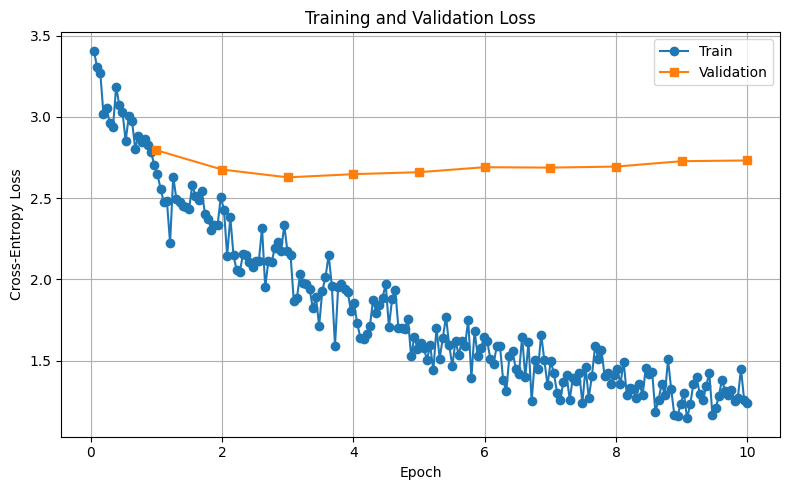

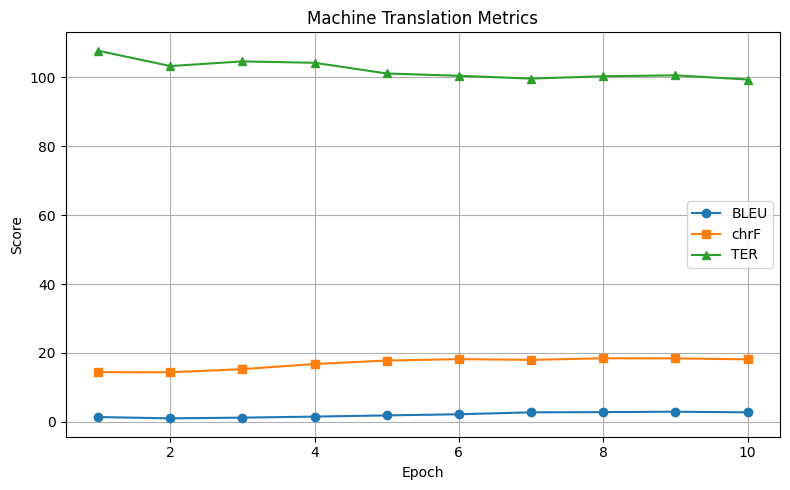

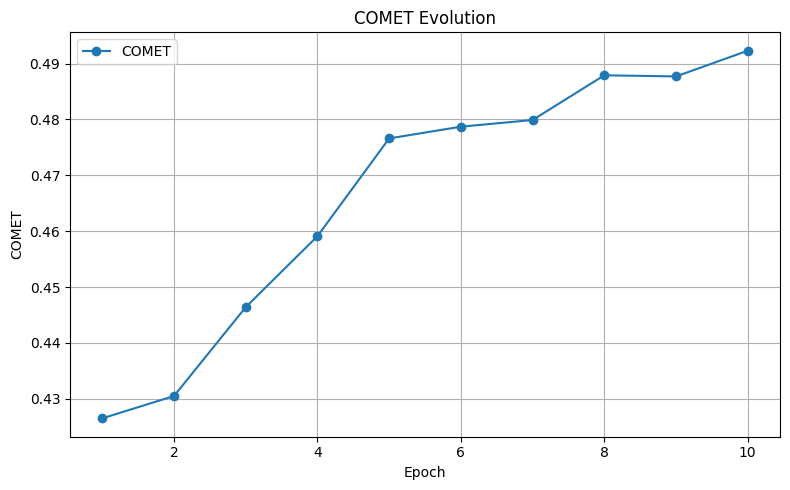

16:07:00 | INFO | Training curves saved.


In [11]:
"""
Cell 10 — Training Dynamics Visualization

Purpose
-------
Visualize optimization behaviour during mBART-50
fine-tuning.

Generated Figures
-----------------
1. Training vs Validation Loss

2. BLEU / chrF / TER

3. Optional COMET progression

These plots can be directly included in an
IEEE paper.

"""

def plot_training_curves(

        log_history,

        output_dir

):

    eval_logs = [

        h

        for h in log_history

        if "eval_loss" in h

    ]

    train_logs = [

        h

        for h in log_history

        if (

            "loss" in h

            and

            "eval_loss"

            not in h

        )

    ]

    os.makedirs(

        output_dir,

        exist_ok=True

    )

    # ==================================================
    # Figure 1
    # ==================================================

    fig = plt.figure(

        figsize=(8,5)

    )

    plt.plot(

        [h["epoch"]

         for h in train_logs],

        [h["loss"]

         for h in train_logs],

        marker="o",

        label="Train"

    )

    plt.plot(

        [h["epoch"]

         for h in eval_logs],

        [h["eval_loss"]

         for h in eval_logs],

        marker="s",

        label="Validation"

    )

    plt.xlabel(

        "Epoch"

    )

    plt.ylabel(

        "Cross-Entropy Loss"

    )

    plt.title(

        "Training and Validation Loss"

    )

    plt.grid(True)

    plt.legend()

    plt.tight_layout()

    plt.savefig(

        f"{output_dir}/24Julyloss_curve.png",

        dpi=300,

        bbox_inches="tight"

    )

    plt.show()


    # ==================================================
    # Figure 2
    # ==================================================

    plt.figure(

        figsize=(8,5)

    )

    if any(

            "eval_bleu" in h

            for h in eval_logs

    ):

        plt.plot(

            [h["epoch"]

             for h in eval_logs],

            [h["eval_bleu"]

             for h in eval_logs],

            marker="o",

            label="BLEU"

        )


    if any(

            "eval_chrf"

            in h

            for h in eval_logs

    ):

        plt.plot(

            [h["epoch"]

             for h in eval_logs],

            [h["eval_chrf"]

             for h in eval_logs],

            marker="s",

            label="chrF"

        )


    if any(

            "eval_ter"

            in h

            for h in eval_logs

    ):

        plt.plot(

            [h["epoch"]

             for h in eval_logs],

            [h["eval_ter"]

             for h in eval_logs],

            marker="^",

            label="TER"

        )

    plt.xlabel(

        "Epoch"

    )

    plt.ylabel(

        "Score"

    )

    plt.title(

        "Machine Translation Metrics"

    )

    plt.grid(True)

    plt.legend()

    plt.tight_layout()

    plt.savefig(

        f"{output_dir}/24Julymt_metrics.png",

        dpi=300,

        bbox_inches="tight"

    )

    plt.show()


    # ==================================================
    # Figure 3
    # ==================================================

    if any(

            "eval_comet"

            in h

            for h in eval_logs

    ):

        plt.figure(

            figsize=(8,5)

        )

        plt.plot(

            [h["epoch"]

             for h in eval_logs],

            [h["eval_comet"]

             for h in eval_logs],

            marker="o",

            label="COMET"

        )

        plt.xlabel(

            "Epoch"

        )

        plt.ylabel(

            "COMET"

        )

        plt.title(

            "COMET Evolution"

        )

        plt.grid(True)

        plt.legend()

        plt.tight_layout()

        plt.savefig(

            f"{output_dir}/24Julycomet_curve.png",

            dpi=300,

            bbox_inches="tight"

        )

        plt.show()


    logger.info(

        "Training curves saved."

    )


plot_training_curves(

    trainer.state.log_history,

    OUTPUT_DIR

)

In [12]:
# =============================================================================
# Generate Predictions on Test Set
# =============================================================================

logger.info("=" * 60)
logger.info("Generating Test Predictions")
logger.info("=" * 60)

test_predictions = trainer.predict(
    test_dataset,
    metric_key_prefix="test"
)

# -------------------------------------------------------------------------
# HuggingFace may return a tuple
# -------------------------------------------------------------------------

pred_ids = test_predictions.predictions

if isinstance(pred_ids, tuple):
    pred_ids = pred_ids[0]

# -------------------------------------------------------------------------
# If predictions are logits, convert to token IDs
# -------------------------------------------------------------------------

if pred_ids.ndim == 3:
    pred_ids = np.argmax(pred_ids, axis=-1)

# -------------------------------------------------------------------------
# Replace ignored label tokens (-100)
# -------------------------------------------------------------------------

label_ids = np.where(
    test_predictions.label_ids != -100,
    test_predictions.label_ids,
    tokenizer.pad_token_id
)

# -------------------------------------------------------------------------
# Decode predictions
# -------------------------------------------------------------------------

pred_text = tokenizer.batch_decode(
    pred_ids,
    skip_special_tokens=True,
    clean_up_tokenization_spaces=True
)

label_text = tokenizer.batch_decode(
    label_ids,
    skip_special_tokens=True,
    clean_up_tokenization_spaces=True
)

# -------------------------------------------------------------------------
# Remove surrounding whitespace
# -------------------------------------------------------------------------

pred_text = [text.strip() for text in pred_text]
label_text = [text.strip() for text in label_text]

logger.info(f"Generated {len(pred_text)} translations.")

16:07:55 | INFO | ============================================================
16:07:55 | INFO | Generating Test Predictions
16:07:55 | INFO | ============================================================
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.


  0%|          | 0/26 [00:00<?, ?it/s]

Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Tr

In [13]:
# =============================================================================
# Cell 11 — Machine Translation Evaluation Metrics
#
# Metrics:
#   1. BLEU
#   2. SacreBLEU
#   3. chrF
#   4. chrF++
#   5. TER
#   6. METEOR
#   7. BERTScore
#   8. COMET
# =============================================================================

import evaluate
import numpy as np
import torch
from comet import download_model, load_from_checkpoint

# -----------------------------------------------------------------------------
# Load Evaluation Metrics
# -----------------------------------------------------------------------------

_bleu = evaluate.load("bleu")
_sacrebleu = evaluate.load("sacrebleu")
_chrf = evaluate.load("chrf")
_ter = evaluate.load("ter")
_meteor = evaluate.load("meteor")
_bertscore = evaluate.load("bertscore")

# -----------------------------------------------------------------------------
# Prepare References
# -----------------------------------------------------------------------------

refs = [[x] for x in label_text]

# -----------------------------------------------------------------------------
# BLEU
# -----------------------------------------------------------------------------

bleu = _bleu.compute(
    predictions=pred_text,
    references=refs
)["bleu"]

# -----------------------------------------------------------------------------
# SacreBLEU
# -----------------------------------------------------------------------------

sacrebleu = _sacrebleu.compute(
    predictions=pred_text,
    references=refs
)["score"]

# -----------------------------------------------------------------------------
# chrF
# -----------------------------------------------------------------------------

chrf = _chrf.compute(
    predictions=pred_text,
    references=refs
)["score"]

# -----------------------------------------------------------------------------
# chrF++
# -----------------------------------------------------------------------------

chrfpp = _chrf.compute(
    predictions=pred_text,
    references=refs,
    word_order=2
)["score"]

# -----------------------------------------------------------------------------
# TER
# -----------------------------------------------------------------------------

ter = _ter.compute(
    predictions=pred_text,
    references=refs
)["score"]

# -----------------------------------------------------------------------------
# METEOR
# -----------------------------------------------------------------------------

meteor = _meteor.compute(
    predictions=pred_text,
    references=refs
)["meteor"]

# -----------------------------------------------------------------------------
# BERTScore
# -----------------------------------------------------------------------------

bertscore = _bertscore.compute(
    predictions=pred_text,
    references=label_text,
    lang="en"
)

bert_f1 = np.mean(bertscore["f1"])

# -----------------------------------------------------------------------------
# COMET
# -----------------------------------------------------------------------------

# Source sentences from the test dataset
src_text = test_df["example_khowar"].tolist()

# Download/load COMET model (downloads only once)
model_path = download_model("Unbabel/wmt22-comet-da")
comet_model = load_from_checkpoint(model_path)

# Prepare COMET input
data = [
    {
        "src": src,
        "mt": pred,
        "ref": ref
    }
    for src, pred, ref in zip(src_text, pred_text, label_text)
]

# Compute COMET
comet_output = comet_model.predict(
    data,
    batch_size=5,      # Same as your training batch size
    gpus=1 if torch.cuda.is_available() else 0
)

comet = comet_output.system_score

# -----------------------------------------------------------------------------
# Print Results
# -----------------------------------------------------------------------------

print("=" * 60)
print("FINAL TEST RESULTS")
print("=" * 60)

print(f"BLEU       : {bleu:.4f}")
print(f"SacreBLEU  : {sacrebleu:.4f}")
print(f"chrF       : {chrf:.4f}")
print(f"chrF++     : {chrfpp:.4f}")
print(f"TER        : {ter:.4f}")
print(f"METEOR     : {meteor:.4f}")
print(f"BERTScore  : {bert_f1:.4f}")
print(f"COMET      : {comet:.4f}")

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\PC\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\PC\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\PC\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

16:11:13 | INFO | Lightning automatically upgraded your loaded checkpoint from v1.8.3.post1 to v2.6.5. To apply the upgrade to your files permanently, run `python -m pytorch_lightning.utilities.upgrade_checkpoint C:\Users\PC\.cache\huggingface\hub\models--Unbabel--wmt22-comet-da\snapshots\2760a223ac957f30acfb18c8aa649b01cf1d75f2\checkpoints\model.ckpt`
16:11:29 | INFO | Encoder model frozen.
16:11:30 | INFO | GPU available: True (cuda), used: True
16:11:30 | INFO | TPU available: False, using: 0 TPU cores
16:11:30 | INFO | 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
16:11:30 | INFO | 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
16:11:30 | INFO | 

FINAL TEST RESULTS
BLEU       : 0.0358
SacreBLEU  : 3.5801
chrF       : 18.9407
chrF++     : 18.4095
TER        : 94.7160
METEOR     : 0.2198
BERTScore  : 0.8823
COMET      : 0.4803


In [14]:
import pandas as pd

results_df = pd.DataFrame({
    "Reference": label_text,
    "Prediction": pred_text
})

results_df.to_csv(
    f"{OUTPUT_DIR}/24_July_NLLB_Urdu_test_predictions.csv",
    index=False,
    encoding="utf-8"
)

print(results_df.head())

                                           Reference  \
0                 The wrestler defeated all of them.   
1                                 My shirt is short.   
2                I am cutting wood with a small axe.   
3  I am eager to go to Peshawar but my father isn...   
4  The carpenter is smoothing the wood with an adze.   

                                          Prediction  
0                      The boy grew up on the couch.  
1                           My eyesight is impaired.  
2                      I am cutting wood from a log.  
3  I don't want to ask for anything in the mornin...  
4                       The teacher is sipping wood.  


In [16]:
results_df[results_df['Reference'] == results_df['Prediction']]

,Reference,Prediction


In [15]:
metrics_df = pd.DataFrame([{
    "BLEU": bleu,
    "chrF": chrf,
    "chrF++": chrfpp,
    "TER": ter,
    "METEOR":meteor,
    "COMET": comet
}])

metrics_df.to_csv(
    f"{OUTPUT_DIR}/24_July_NLLB_Urdu_test_metrics.csv",
    index=False
)

metrics_df

,BLEU,chrF,chrF++,TER,METEOR,COMET
0,0.035801,18.940706,18.409546,94.715984,0.219833,0.48026


In [17]:
#  Function to count word overlaps
def word_overlap(ref, pred):
    ref_words = set(ref.split())
    pred_words = set(pred.split())
    overlap = ref_words.intersection(pred_words)
    return len(overlap), list(overlap)

# Apply function row by row
results_df["Overlap_Count"] = results_df.apply(lambda row: word_overlap(row["Reference"], row["Prediction"])[0], axis=1)
results_df["Overlap_Words"] = results_df.apply(lambda row: word_overlap(row["Reference"], row["Prediction"])[1], axis=1)

# Show results with index
for idx, row in results_df.iterrows():
    print(f"Sentence {idx}:")
    print(f"  Reference   : {row['Reference']}")
    print(f"  Prediction  : {row['Prediction']}")
    print(f"  Overlap     : {row['Overlap_Count']} words -> {row['Overlap_Words']}")
    print()

Sentence 0:
  Reference   : The wrestler defeated all of them.
  Prediction  : The boy grew up on the couch.
  Overlap     : 1 words -> ['The']

Sentence 1:
  Reference   : My shirt is short.
  Prediction  : My eyesight is impaired.
  Overlap     : 2 words -> ['is', 'My']

Sentence 2:
  Reference   : I am cutting wood with a small axe.
  Prediction  : I am cutting wood from a log.
  Overlap     : 5 words -> ['a', 'wood', 'cutting', 'am', 'I']

Sentence 3:
  Reference   : I am eager to go to Peshawar but my father isn't allowing me.
  Prediction  : I don't want to ask for anything in the morning; I won't ask for anything.
  Overlap     : 2 words -> ['I', 'to']

Sentence 4:
  Reference   : The carpenter is smoothing the wood with an adze.
  Prediction  : The teacher is sipping wood.
  Overlap     : 2 words -> ['is', 'The']

Sentence 5:
  Reference   : I didn't enjoy the celebration much.
  Prediction  : He/she didn't find any money.
  Overlap     : 1 words -> ["didn't"]

Sentence 6:
  Re

In [20]:
import pandas as pd
from sentence_transformers import SentenceTransformer, util

# Load your CSV file
df = pd.read_csv(r"checkpoints\nllb_khowar_v1\NLLB_Urdu_test_predictions.csv")

# Make sure your CSV has columns named "Reference" and "Prediction"
print(df.head())

# Load semantic similarity model
model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')

# Lexical similarity (Jaccard index)
def jaccard_similarity(ref, pred):
    ref_set = set(ref.lower().split())
    pred_set = set(pred.lower().split())
    intersection = ref_set.intersection(pred_set)
    union = ref_set.union(pred_set)
    return len(intersection) / len(union) if union else 0.0

# Semantic similarity (cosine similarity of embeddings)
def semantic_similarity(ref, pred):
    embeddings = model.encode([ref, pred])
    return util.cos_sim(embeddings[0], embeddings[1]).item()

# Apply functions to each row
df["Lexical_Similarity"] = df.apply(lambda row: jaccard_similarity(str(row["Reference"]), str(row["Prediction"])), axis=1)
df["Semantic_Similarity"] = df.apply(lambda row: semantic_similarity(str(row["Reference"]), str(row["Prediction"])), axis=1)

# Save results to a new CSV
output_path = r"checkpoints\nllb_khowar_v1\NLLB_Urdu_test_predictions_with_scores.csv"
df.to_csv(output_path, index=False)

print(f"Similarity scores saved to: {output_path}")


16:20:42 | INFO | No device provided, using cuda:0


                                           Reference  \
0           People in the old days were very simple.   
1             I didn't hit the target with my rifle.   
2               A bundle of fodder is twenty rupees.   
3  The father of my son/daughter-in-law is a very...   
4                 The wrestler defeated all of them.   

                                  Prediction  
0                   The old ways are simple.  
1             He/she didn't touch my finger.  
2  There are twenty-two rupees in the house.  
3                     My stomach is hurting.  
4                 The boy grew up on a sofa.  


16:20:43 | INFO | Loading SentenceTransformer model from sentence-transformers/all-MiniLM-L6-v2.


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

...

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Similarity scores saved to: checkpoints\nllb_khowar_v1\NLLB_Urdu_test_predictions_with_scores.csv


In [21]:
# Top 20 highest semantic similarity
top20 = df.nlargest(20, "Semantic_Similarity")

print("Top 10 highest semantic similarity:")
top20[["Reference", "Prediction", "Semantic_Similarity"]]


Top 10 highest semantic similarity:


,Reference,Prediction,Semantic_Similarity
44,Grind the grain fine.,Have a drink of grain.,0.685798
99,Why are you sitting so quietly?,Why are you sitting here?,0.684287
14,Friday was three days before today.,Friday morning came.,0.679706
75,He sacrificed a bull.,The calf made a sacrifice.,0.654914
100,There is a lot of gold in Chitral.,There are many dwellings in Chitral.,0.640728
2,A bundle of fodder is twenty rupees.,There are twenty-two rupees in the house.,0.638755
17,Why are you leaving without having tea?,Are you going to make tea or not?,0.606497
63,When the donkey brayed he got a burden.,The donkey is going out.,0.604424
36,Someone is knocking at the door.,The door is creaking.,0.600090
25,"Since it didn't rain last year, the land dried...",Because of drought the ground wasn't polluted.,0.594642


In [22]:
# Top 10 lowest semantic similarity
lowest20 = df.nsmallest(20, "Semantic_Similarity")



print("\nTop 20 lowest semantic similarity:")
lowest20[["Reference", "Prediction", "Semantic_Similarity"]]


Top 20 lowest semantic similarity:


,Reference,Prediction,Semantic_Similarity
4,The wrestler defeated all of them.,The boy grew up on a sofa.,-0.094143
66,A straight piece of wood can be made into a pi...,There are many springs in the valley.,0.003855
91,The apricots are finished.,The lid of the stall has become loose.,0.004096
40,Iron can be made usable after straightening.,There are ten households in Chumru-Froski.,0.007420
27,Cooked fenugreek is slightly bitter.,A spider's tail is short for a spider's tail.,0.008865
35,They rattled the metallic things and left at n...,He/she has slaughtered a goat and slaughtered ...,0.010764
37,"O, the sweet scent of the beloved is even more...",A snapping turtle is good for all its friends.,0.022935
60,The wind blows a lot at elevated places.,The Duke is singing a song of praise.,0.025842
3,The father of my son/daughter-in-law is a very...,My stomach is hurting.,0.030408
88,"When the patient died, his brother arranged hi...","When the rice is cooked thoroughly, the onions...",0.041346


In [23]:

# Top 20 highest lexical similarity
top20_lexical = df.nlargest(20, "Lexical_Similarity")

print("Top 20 highest lexical similarity:")
top20_lexical[["Reference", "Prediction", "Lexical_Similarity"]]



Top 20 highest lexical similarity:


,Reference,Prediction,Lexical_Similarity
99,Why are you sitting so quietly?,Why are you sitting here?,0.571429
20,He/she didn't understand.,He/she didn't eat anything.,0.400000
29,Do you want to say something else?,What do you want to give me?,0.400000
65,Why are the two of you sitting idle?,Why are you walking underneath the bridge?,0.363636
12,Who are shouting outside?,Who are you toasting?,0.333333
0,People in the old days were very simple.,The old ways are simple.,0.300000
48,The reed pen is writing beautifully.,The white pen is making happy signals.,0.300000
33,My cow is pregnant.,My daughter-in-law is married off.,0.285714
87,"Having recovered, he/she is walking.",He/she is cutting wood.,0.285714
100,There is a lot of gold in Chitral.,There are many dwellings in Chitral.,0.272727


In [24]:

# Top 20 lowest lexical similarity
lowest20_lexical = df.nsmallest(20, "Lexical_Similarity")


print("\nTop 20 lowest lexical similarity:")
lowest20_lexical[["Reference", "Prediction", "Lexical_Similarity"]]


Top 20 lowest lexical similarity:


,Reference,Prediction,Lexical_Similarity
2,A bundle of fodder is twenty rupees.,There are twenty-two rupees in the house.,0.0
5,Wind took the straw away.,Your son is gone.,0.0
7,Where did you find this?,Shall we go?,0.0
11,One who has property has no problems.,What a gift you have made.,0.0
23,There is a lot of fruit on the apple trees.,Ploughs are beautifully decorated.,0.0
24,Gunpowder can be made from saltpeter.,Rice is good with buttermilk.,0.0
26,Who brought you?,Did you come to Peshawar?,0.0
30,When I saw the leopard I started trembling unc...,He/she slaughtered a female goat and slaughter...,0.0
31,Five fingers are not equal in size.,He/she didn't come out to kiss the flower.,0.0
39,Were you able to sell anything today?,Has he/she slaughtered sheep or goats?,0.0
